# Event Selection

**_must run with dfs will all reconstructed slices_**

This notebook runs the full event selection, evaluating selection performance

- runs cosmic rejection and optimized cuts from `inspect_variables.ipynb`
- makes mode breakdown bar plots for each selection stage
- makes purity/efficiency summary plots

In [79]:
%load_ext autoreload
%autoreload 2

#print all output
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt 
import sys
from os import path
from tqdm import tqdm
import datetime

# local imports
sys.path.append('../../')
from analysis_village.numucc_1p0pi.selection_definitions import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from pyanalib.split_df_helpers import *
from pyanalib.stat_helpers import *
from pyanalib.pandas_helpers import *
from pyanalib.variable_calculator import get_cc1p0pi_tki
from pyanalib.pandas_helpers import pad_column_name
from makedf.constants import *

plt.style.use("presentation.mplstyle")
# cmap = mpl.cm.viridis
# norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)

# suppress warnings
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [81]:
save_fig = False
today_str = datetime.datetime.now().strftime("%Y%m%d")
print(today_str)
save_fig_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/event_selection-GiBUU"

20260124


In [82]:
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025B_v10_06_00_09"
## -- MC 
# mc_file = path.join(file_dir, "BNB_cosmics.df")
mc_file = path.join(file_dir, "BNB_cosmics_GiBUU.df")
# mc_file = path.join(file_dir, "lowE_dirt.df")
mc_split_df = pd.read_hdf(mc_file, key="split")
mc_n_split = get_n_split(mc_file)
print("mc_n_split: %d" %(mc_n_split))
print_keys(mc_file)

## -- Data
data_file = path.join(file_dir, "data_bnblight.df")
data_split_df = pd.read_hdf(data_file, key="split")
data_n_split = get_n_split(data_file)
print("data_n_split: %d" %(data_n_split))
print_keys(data_file)

mc_n_split: 7
Keys: ['/evt_0', '/evt_1', '/evt_2', '/evt_3', '/evt_4', '/evt_5', '/evt_6', '/hdr_0', '/hdr_1', '/hdr_2', '/hdr_3', '/hdr_4', '/hdr_5', '/hdr_6', '/mcnu_0', '/mcnu_1', '/mcnu_2', '/mcnu_3', '/mcnu_4', '/mcnu_5', '/mcnu_6', '/split', '/trk_0', '/trk_1', '/trk_2', '/trk_3', '/trk_4', '/trk_5', '/trk_6']
data_n_split: 2
Keys: ['/bnbpot_0', '/bnbpot_1', '/evt_0', '/evt_1', '/hdr_0', '/hdr_1', '/split', '/trk_0', '/trk_1']


In [83]:
# concat dfs 
n_max_concat = 3

mc_keys2load = ['hdr', 'evt', 'trk', 'mcnu']
mc_dfs = load_dfs(mc_file, mc_keys2load, n_max_concat=n_max_concat)
mc_hdr_df = mc_dfs['hdr']
mc_evt_df = mc_dfs['evt']
mc_trk_df = mc_dfs['trk']
mc_mcnu_df = mc_dfs['mcnu']

data_keys2load = ['hdr', 'evt', 'trk']
data_dfs = load_dfs(data_file, data_keys2load, n_max_concat=n_max_concat)
data_hdr_df = data_dfs['hdr']
data_evt_df = data_dfs['evt']
data_trk_df = data_dfs['trk']

In [84]:
## total pot - scale to data POT

# BNB data
# data_tot_pot = data_hdr_df['TOR875'].sum()
data_tot_pot = data_hdr_df['pot'].sum()
# data_tot_pot = 4.60e+18
print("data_tot_pot: %.3e" %(data_tot_pot))
pot_str = "7.37 $\\times 10^{18}$"
data_evt_df["pot_weight"] = np.ones(len(data_evt_df))
data_trk_df["pot_weight"] = np.ones(len(data_trk_df))
data_gates = data_hdr_df.nbnbinfo.sum()
print("data tot gates : %.3e" %(data_gates))

# BNB MC
mc_tot_pot = mc_hdr_df['pot'].sum()
print("mc_tot_pot: %.3e" %(mc_tot_pot))
mc_pot_scale = data_tot_pot / mc_tot_pot
print("mc_pot_scale: %.3e" %(mc_pot_scale))

mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
mc_trk_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_trk_df))

# Intime Data
# basepath = "/exp/sbnd/data/users/munjung/xsec/2025B"
# fname = "trash/Data_intime_1000.df"
# intime_hdr_df = pd.read_hdf(path.join(basepath, fname), "hdr")
# intime_evt_df = pd.read_hdf(path.join(basepath, fname), "slc")
# intime_trk_df = pd.read_hdf(path.join(basepath, fname), "trk")

intime_file = "data_intime_1000.df"
data_keys2load = ['hdr', 'evt', 'trk']
intime_dfs = load_dfs(path.join(file_dir, intime_file), data_keys2load, n_max_concat=n_max_concat)
intime_hdr_df = intime_dfs['hdr']
intime_evt_df = intime_dfs['evt']
intime_trk_df = intime_dfs['trk']

# intime_gates = intime_hdr.noffbeambnb.sum()
intime_gates = intime_hdr_df[intime_hdr_df['first_in_subrun'] == 1]['noffbeambnb'].sum()
print("intime cosmics data gates: {:.2e}".format(intime_gates))
f = 0.073
scale_intime_to_lightdata = (1-f)*data_gates/intime_gates
print("goal scale: {:.2f}".format(scale_intime_to_lightdata))
intime_evt_df["gates_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))
intime_trk_df["gates_weight"] = scale_intime_to_lightdata * np.ones(len(intime_trk_df))

data_tot_pot: 5.950e+18
data tot gates : 1.251e+06
mc_tot_pot: 1.771e+19
mc_pot_scale: 3.360e-01


intime cosmics data gates: 2.34e+06
goal scale: 0.50


In [85]:
plot_labels_bar = ["Events (POT={})".format(pot_str), "", ""]
plot_labels_hist = ["", "Events (POT={})".format(pot_str), ""]

In [86]:
df_dict = {} # for efficiency plot
df_dict_data = {} # for efficiency plot
df_dict_intime = {} # for efficiency plot
perc_dict_topo = {} # for topo break-down plot
perc_dict_genie = {} # for genie break-down plot

In [87]:
generator = "GiBUU"
show_plot = True

# Event Selection

In [88]:
def avg_chi2(df, var_name):
    planes = ['I0', 'I1', 'I2']
    # planes = ['I2']
    chi2_vals = []
    for plane in planes:
        chi2 = df['pfp']['trk']['chi2pid'][plane][var_name]
        chi2_vals.append(chi2)
    chi2_df = pd.concat(chi2_vals, axis=1)
    # fill 0 with nan
    chi2_df = chi2_df.replace(0, np.nan)
    avg = chi2_df.mean(axis=1, skipna=True)
    return avg

In [89]:
def cut_clear_cosmic(df):
    return df[df.slc.is_clear_cosmic == 0]

def cut_vertex_in_fv(df):
    return df[InFV(df.slc.vertex, det=DETECTOR)]

def cut_nu_score(df, th=0.5):
    return df[df.slc.nu_score > th]

def get_valid_trks(df):
    return df[df.pfp.trk.producer != 4294967295]

def cut_good_trks(trkdf):
    mask = (trkdf.pfp.trk.len > 0) &\
         (trkdf.pfp.pfochar.vtxdist < 100) #&\
    return trkdf[mask]

def get_trk_info(evtdf, trkdf, save_ntrks=3):
    ntrks = trkdf.pfp.id.groupby(level=[0,1,2]).count()
    ntrks.reindex(evtdf.index, fill_value=0)
    evtdf["n_trks"] = ntrks

    good_trks = cut_good_trks(trkdf).copy()
    ntrks = good_trks.pfp.id.groupby(level=[0,1,2]).count()
    ntrks.reindex(evtdf.index, fill_value=0)
    evtdf["n_good_trks"] = ntrks

    trks_sorted = trkdf.sort_values(by=('pfp','trk','len'), ascending=False)
    good_trks_sorted = good_trks.sort_values(by=('pfp','trk','len'), ascending=False)
    # get 'ntrks' longest tracks
    for i in range(save_ntrks):
        trk_i = good_trks_sorted.groupby(level=[0,1,2]).nth(i)
        trk_i.columns = pd.MultiIndex.from_tuples([tuple(["nocut_trk" + str(i+1)] + list(c)) for c in trk_i.columns])
        evtdf = multicol_merge(evtdf, trk_i.droplevel(-1), left_index=True, right_index=True, how="left", validate="one_to_one")

        good_trk_i = good_trks_sorted.groupby(level=[0,1,2]).nth(i)
        good_trk_i.columns = pd.MultiIndex.from_tuples([tuple(["trk" + str(i+1)] + list(c)) for c in good_trk_i.columns])
        evtdf = multicol_merge(evtdf, good_trk_i.droplevel(-1), left_index=True, right_index=True, how="left", validate="one_to_one")

    return evtdf


def cut_2prong(df):
    # return df[(df.n_good_trks == 2) & (df.n_trks <= 3)]
    return df[(df.n_good_trks == 2)]

def cut_2prong_contained(df):
    return df[InFV(df.trk1.pfp.trk.start, det=DETECTOR) & InFV(df.trk1.pfp.trk.end, det=DETECTOR) \
        & InFV(df.trk2.pfp.trk.start, det=DETECTOR) & InFV(df.trk2.pfp.trk.end, det=DETECTOR)]

def cut_2prong_trackscore(df, trackscore_th=0.5):
    return df[(df.trk1.pfp.trackScore > trackscore_th) & (df.trk2.pfp.trackScore > trackscore_th)]

def cut_2prong_vtxdist(df, vtxdist_th=1.5):
    return df[(df.trk1.pfp.pfochar.vtxdist < vtxdist_th) & (df.trk2.pfp.pfochar.vtxdist < vtxdist_th)]

def get_mu_p_candidate(df, 
                       mu_chi2mu_th=30, mu_chi2p_th=100, mu_len_th=50, qual_th=0.25,
                       p_chi2mu_th=30, p_chi2p_th=90, p_len_th=0):

    trks = pd.concat([df.trk1, df.trk2])

    chimu_avg = avg_chi2(trks, "chi2_muon")
    chip_avg = avg_chi2(trks, "chi2_proton")

    mcs_range_diff = np.abs((trks.pfp.trk.rangeP.p_muon - trks.pfp.trk.mcsP.fwdP_muon) / trks.pfp.trk.rangeP.p_muon)

    mu_cut = (chimu_avg > 0) & (chimu_avg < mu_chi2mu_th) & \
            (chip_avg > mu_chi2p_th) & \
            (trks.pfp.trk.len > mu_len_th) & \
            (mcs_range_diff < qual_th)

    mu_candidate = trks[mu_cut]
    mu_candidate = mu_candidate.groupby(level=[0,1,2]).nth(0)

    mu_candidate.columns = pd.MultiIndex.from_tuples([tuple(["mu_cand"] + list(c)) for c in mu_candidate.columns])
    df = multicol_merge(df, mu_candidate, left_index=True, right_index=True, how="left", validate="one_to_one")

    # TODO: keep & use original trk index?
    not_mu_candidate = pd.concat([trks[~mu_cut], trks[mu_cut].groupby(level=[0,1,2]).nth(1)])
    chip_avg = avg_chi2(not_mu_candidate, "chi2_proton")
    p_candidate = not_mu_candidate[(chip_avg > 0) & (chip_avg < p_chi2p_th) & (not_mu_candidate.pfp.trk.len > p_len_th)]
    p_candidate = p_candidate.groupby(level=[0,1,2]).nth(0)

    p_candidate.columns = pd.MultiIndex.from_tuples([tuple(["p_cand"] + list(c)) for c in p_candidate.columns])
    df = multicol_merge(df, p_candidate, left_index=True, right_index=True, how="left", validate="one_to_one")

    return df

In [90]:
def cut_has_mu(df):
    return df[~np.isnan(df.mu_cand.pfp.trk.producer)]

def cut_has_p(df):
    return df[~np.isnan(df.p_cand.pfp.trk.producer)]

In [91]:
def cut_mu_kinematics(df, mu_Plo_th=0.22, mu_Phi_th= 1):
    return df[(df.mu_cand.pfp.trk.rangeP.p_muon > mu_Plo_th) & (df.mu_cand.pfp.trk.rangeP.p_muon < mu_Phi_th)]

def cut_p_kinematics(df, p_Plo_th=0.3, p_Phi_th= 1):
    return df[(df.p_cand.pfp.trk.rangeP.p_proton > p_Plo_th) & (df.p_cand.pfp.trk.rangeP.p_proton < p_Phi_th)]

In [92]:
nu_score_th = 0.45

save_ntrks = 3

trackscore_th = 0.5

vtxdist_th = 1.2

mu_chi2mu_th = 30
mu_chi2p_th = 100
mu_len_th = 50

qual_th = 0.2

p_chi2p_th = 90
p_len_th = 0

mu_Plo_th = 0.22
mu_Phi_th = 1
p_Plo_th = 0.3
p_Phi_th = 1

## Cosmic Rejection

In [93]:
def plot_bar_plots(stage_key, mc_evt_df, show_plot=True):
    bar_type = "nu_cosmics"
    save_name = save_fig_dir + "/bar_plot-{}-{}.png".format(bar_type, stage_key)
    ret_nu_cosmics = bar_plot(breakdown_type=bar_type, generator=generator, 
                            evtdf=mc_evt_df,
                            show_plot=show_plot, plot_labels=plot_labels_bar,
                            save_fig=save_fig, save_name=save_name)

    bar_type = "topology"
    save_name = save_fig_dir + "/bar_plot-{}-{}.png".format(bar_type, stage_key)
    ret_topo = bar_plot(breakdown_type=bar_type, generator=generator, 
                        evtdf=mc_evt_df,
                        show_plot=show_plot, plot_labels=plot_labels_bar,
                        save_fig=save_fig, save_name=save_name)

    bar_type = "genie"
    save_name = save_fig_dir + "/bar_plot-{}-{}.png".format(bar_type, stage_key)
    ret_genie = bar_plot(breakdown_type=bar_type, generator=generator, 
                        evtdf=mc_evt_df,
                        show_plot=show_plot, plot_labels=plot_labels_bar,
                        save_fig=save_fig, save_name=save_name)
                        
    return {"nu_cosmics": ret_nu_cosmics, "topology": ret_topo, "genie": ret_genie}

ValueError: Axis limits cannot be NaN or Inf

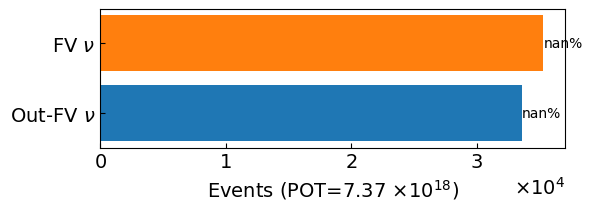

In [94]:
stage_key = "allreco"

mc_df = mc_evt_df
data_df = data_evt_df
intime_df = intime_evt_df

ret = plot_bar_plots(stage_key, mc_df, show_plot=show_plot)

# save dfs
df_dict[stage_key] = mc_df
df_dict_data[stage_key] = data_df
df_dict_intime[stage_key] = intime_df

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

numu NC 12880


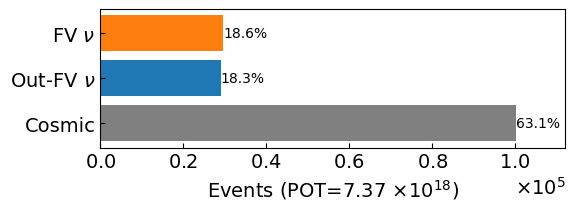

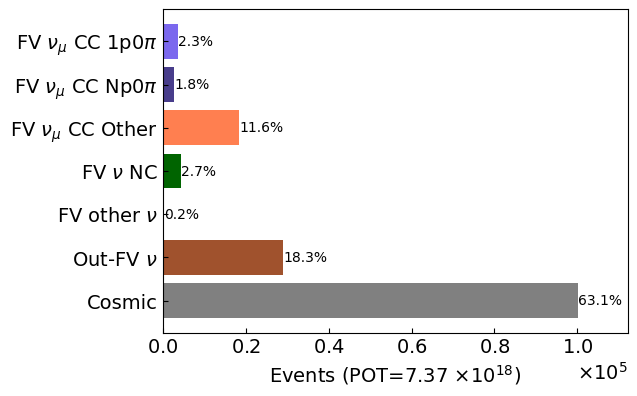

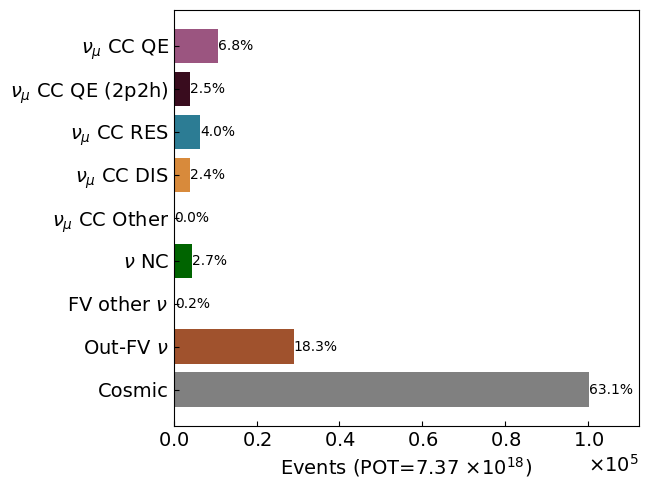

In [ ]:
stage_key = "is_clear_cosmic"

# dfs
mc_df = cut_clear_cosmic(mc_df)
data_df = cut_clear_cosmic(data_df)
intime_df = cut_clear_cosmic(intime_df)

ret = plot_bar_plots(stage_key, mc_df, show_plot=show_plot)

# save dfs
df_dict[stage_key] = mc_df
df_dict_data[stage_key] = data_df
df_dict_intime[stage_key] = intime_df

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

numu NC 12042


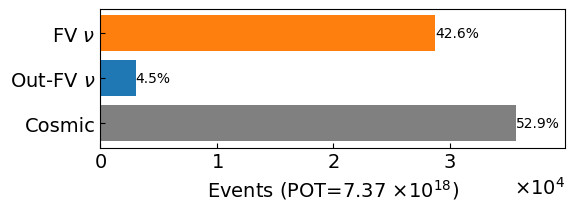

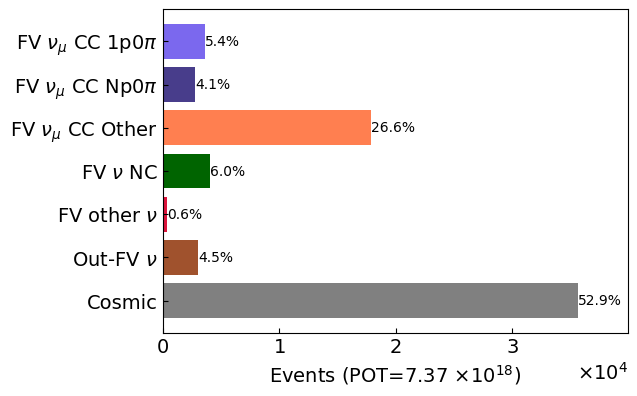

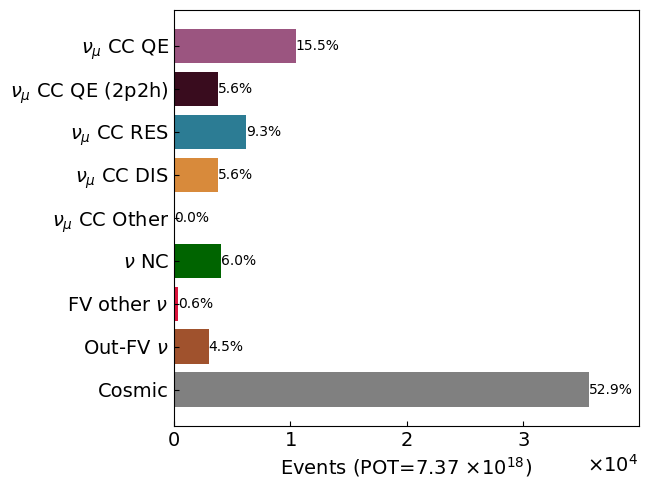

In [ ]:
stage_key = "vertex_in_fv"

# dfs
mc_df = cut_vertex_in_fv(mc_df)
data_df = cut_vertex_in_fv(data_df)
intime_df = cut_vertex_in_fv(intime_df)

ret = plot_bar_plots(stage_key, mc_df, show_plot=show_plot)

# save dfs
df_dict[stage_key] = mc_df
df_dict_data[stage_key] = data_df
df_dict_intime[stage_key] = intime_df

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

numu NC 9105


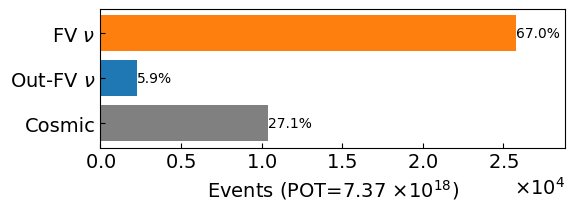

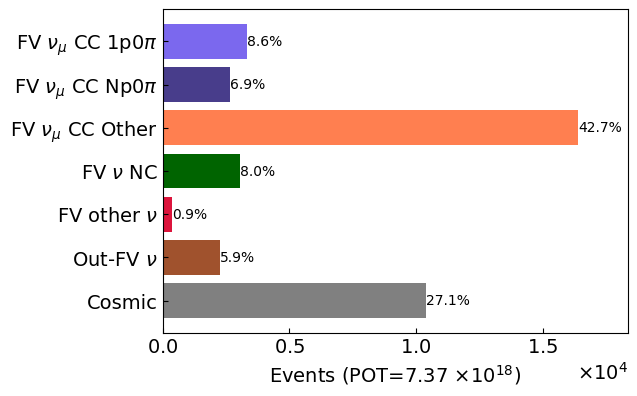

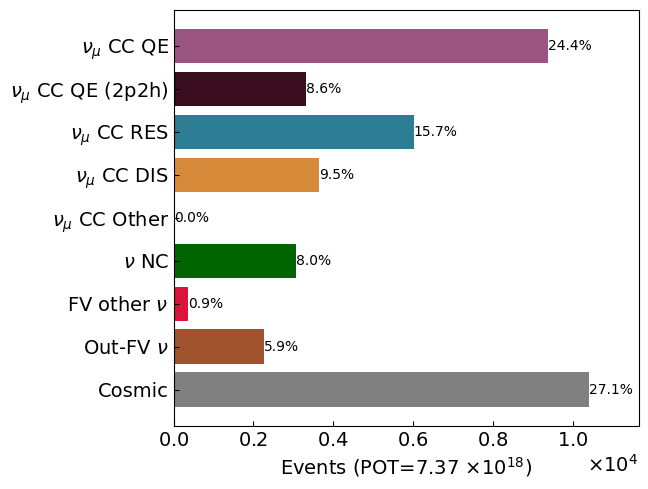

In [ ]:
stage_key = "nu_score"

# dfs
mc_df = cut_nu_score(mc_df, nu_score_th)
data_df = cut_nu_score(data_df, nu_score_th)
intime_df = cut_nu_score(intime_df, nu_score_th)

ret = plot_bar_plots(stage_key, mc_df, show_plot=show_plot)

# save dfs
df_dict[stage_key] = mc_df
df_dict_data[stage_key] = data_df
df_dict_intime[stage_key] = intime_df

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

## Slice has at least two tracks

In [ ]:
mc_trk_df = get_valid_trks(mc_trk_df)
data_trk_df = get_valid_trks(data_trk_df)
intime_trk_df = get_valid_trks(intime_trk_df)

In [ ]:
mc_trk_df = match_trkdf_to_slcdf(mc_trk_df, mc_df)
data_trk_df = match_trkdf_to_slcdf(data_trk_df, data_df)
intime_trk_df = match_trkdf_to_slcdf(intime_trk_df, intime_df)

min, max: -9999.00, 622.76


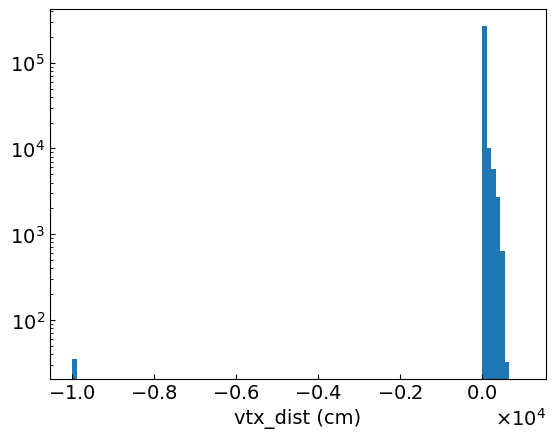

In [ ]:
# inspect "good track" cut variables
var = mc_trk_df.pfp.pfochar.vtxdist
print("min, max: %.2f, %.2f" %(var.min(), var.max()))
bins = np.linspace(-1e4, 1e3, 100)
plt.hist(var, bins=bins)
plt.xlabel("vtx_dist (cm)")
plt.yscale("log")
plt.show();

In [ ]:
mc_df = get_trk_info(mc_df, mc_trk_df, save_ntrks)
data_df = get_trk_info(data_df, data_trk_df, save_ntrks)
intime_df = get_trk_info(intime_df, intime_trk_df, save_ntrks)


/tmp/ipykernel_856883/2179848488.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evtdf["n_trks"] = ntrks
/tmp/ipykernel_856883/2179848488.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evtdf["n_good_trks"] = ntrks
/tmp/ipykernel_856883/2179848488.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

numu NC 2595


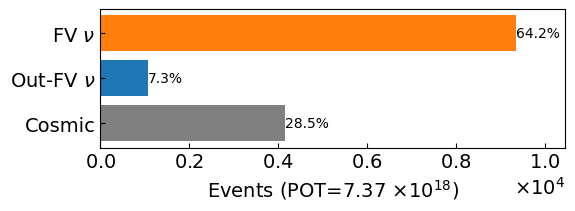

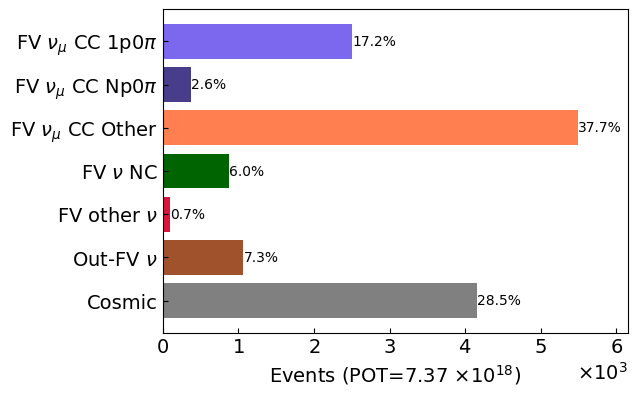

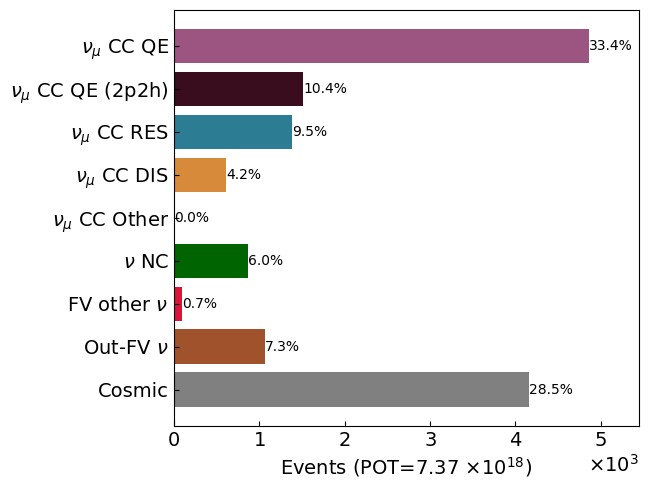

In [ ]:
stage_key = "2prong"

# dfs
mc_df = cut_2prong(mc_df)
data_df = cut_2prong(data_df)
intime_df = cut_2prong(intime_df)

ret = plot_bar_plots(stage_key, mc_df, show_plot=show_plot)

# save dfs
df_dict[stage_key] = mc_df
df_dict_data[stage_key] = data_df
df_dict_intime[stage_key] = intime_df

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

numu NC 2093


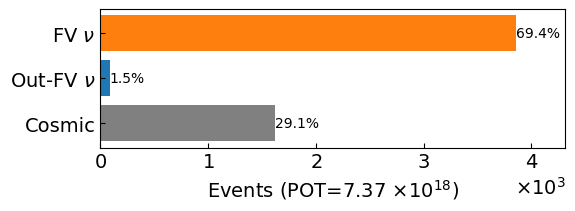

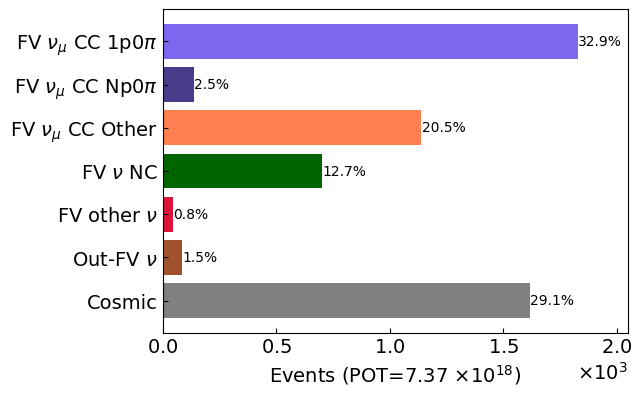

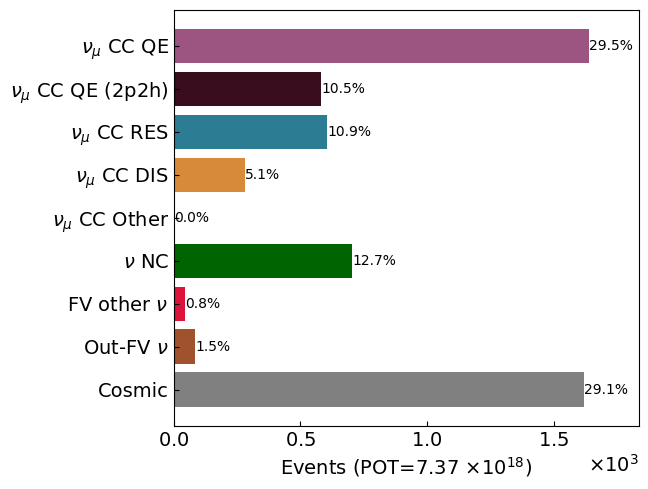

In [ ]:
stage_key = "2prong-contained"

# dfs
mc_df = cut_2prong_contained(mc_df)
data_df = cut_2prong_contained(data_df)
intime_df = cut_2prong_contained(intime_df)

ret = plot_bar_plots(stage_key, mc_df, show_plot=show_plot)

# save dfs
df_dict[stage_key] = mc_df
df_dict_data[stage_key] = data_df
df_dict_intime[stage_key] = intime_df

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

numu NC 1275


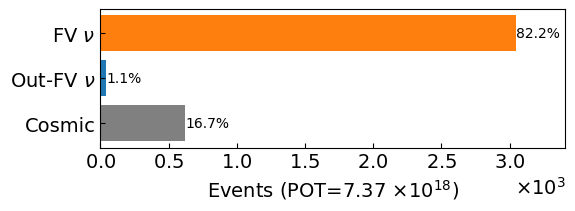

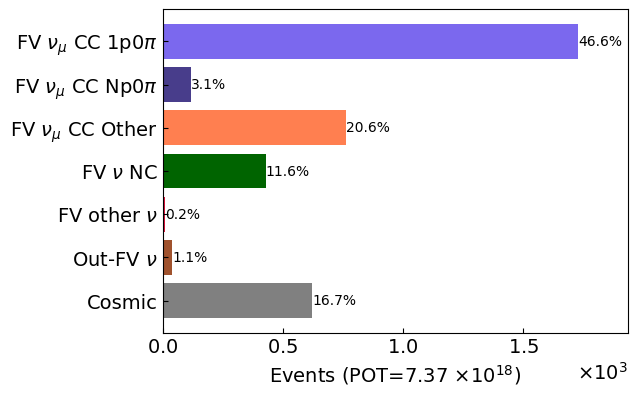

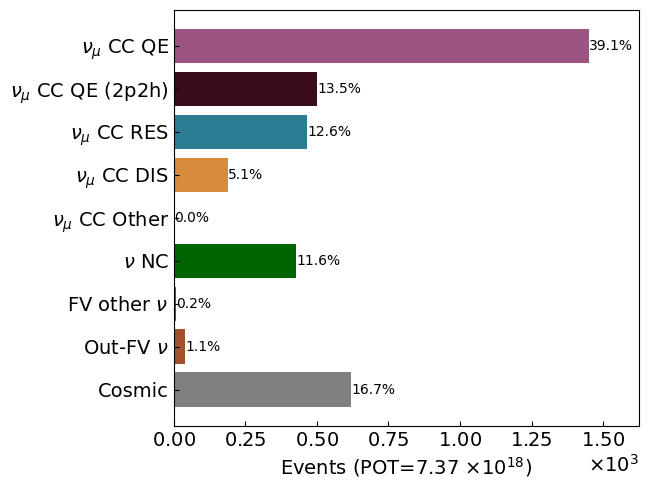

In [ ]:
stage_key = "2prong-trackscore"

# dfs
mc_df = cut_2prong_trackscore(mc_df, trackscore_th)
data_df = cut_2prong_trackscore(data_df, trackscore_th)
intime_df = cut_2prong_trackscore(intime_df, trackscore_th)

ret = plot_bar_plots(stage_key, mc_df, show_plot=show_plot)

# save dfs
df_dict[stage_key] = mc_df
df_dict_data[stage_key] = data_df
df_dict_intime[stage_key] = intime_df

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

numu NC 902


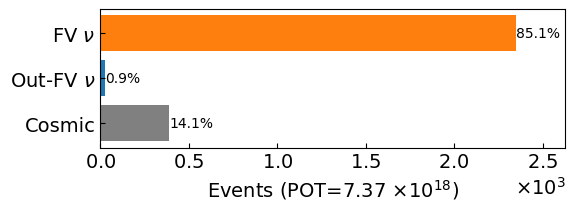

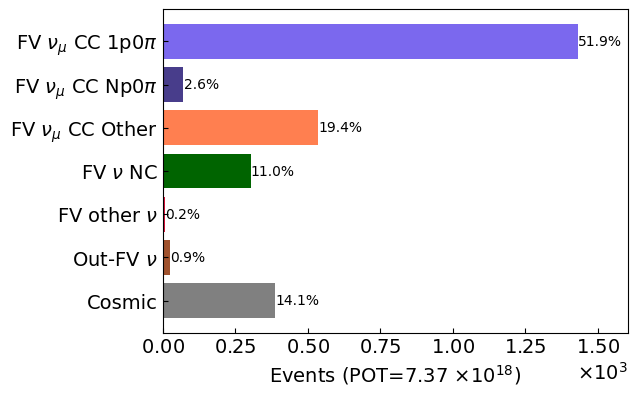

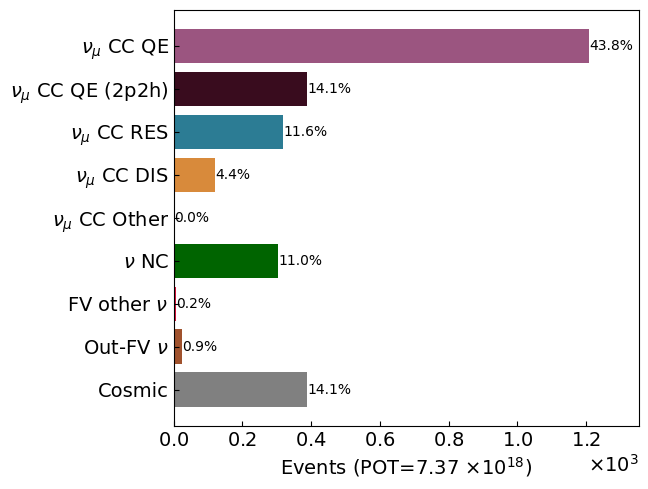

In [ ]:
stage_key = "2prong-vtxdist"

# dfs
mc_df = cut_2prong_vtxdist(mc_df, vtxdist_th)
data_df = cut_2prong_vtxdist(data_df, vtxdist_th)
intime_df = cut_2prong_vtxdist(intime_df, vtxdist_th)

ret = plot_bar_plots(stage_key, mc_df, show_plot=show_plot)

# save dfs
df_dict[stage_key] = mc_df
df_dict_data[stage_key] = data_df
df_dict_intime[stage_key] = intime_df

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

## PID

In [ ]:
mc_df = get_mu_p_candidate(mc_df, 
                       mu_chi2mu_th=mu_chi2mu_th, mu_chi2p_th=mu_chi2p_th, mu_len_th=mu_len_th, qual_th=qual_th,
                       p_chi2mu_th=-1, p_chi2p_th=p_chi2p_th, p_len_th=p_len_th)
data_df = get_mu_p_candidate(data_df, 
                       mu_chi2mu_th=mu_chi2mu_th, mu_chi2p_th=mu_chi2p_th, mu_len_th=mu_len_th, qual_th=qual_th,
                       p_chi2mu_th=-1, p_chi2p_th=p_chi2p_th, p_len_th=p_len_th)
intime_df = get_mu_p_candidate(intime_df,
                       mu_chi2mu_th=mu_chi2mu_th, mu_chi2p_th=mu_chi2p_th, mu_len_th=mu_len_th, qual_th=qual_th,
                       p_chi2mu_th=-1, p_chi2p_th=p_chi2p_th, p_len_th=p_len_th)

numu NC 54


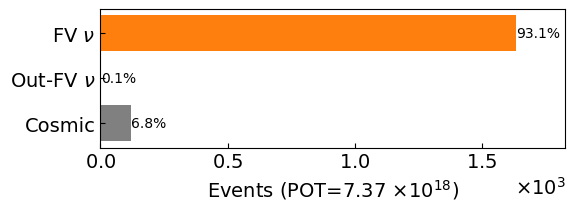

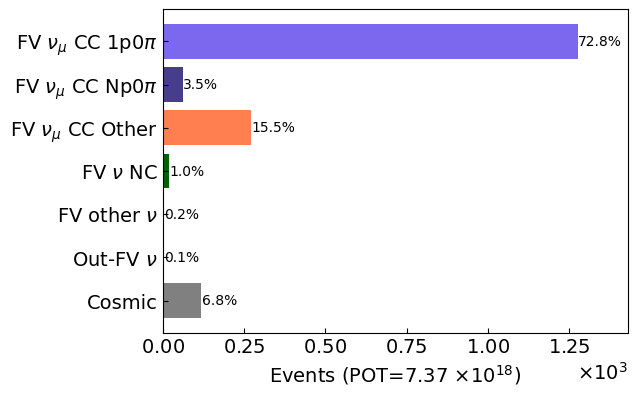

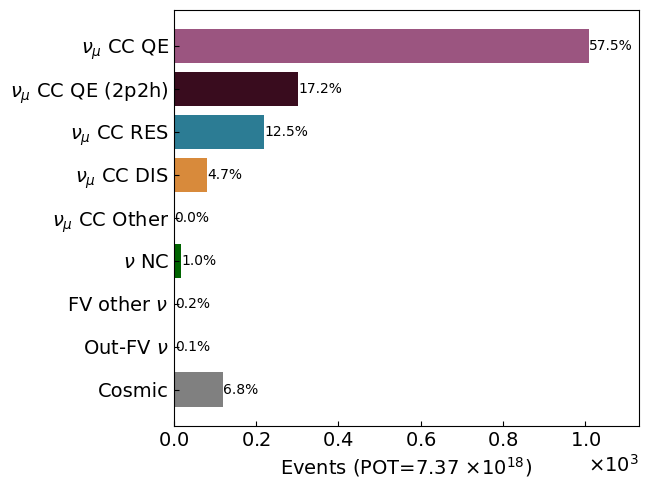

In [ ]:
stage_key = "2prong-muX"

# dfs
mc_df = cut_has_mu(mc_df) 
mc_df = cut_mu_kinematics(mc_df, mu_Plo_th=mu_Plo_th, mu_Phi_th=mu_Phi_th)
data_df = cut_has_mu(data_df) 
data_df = cut_mu_kinematics(data_df, mu_Plo_th=mu_Plo_th, mu_Phi_th=mu_Phi_th)
intime_df = cut_has_mu(intime_df)
intime_df = cut_mu_kinematics(intime_df, mu_Plo_th=mu_Plo_th, mu_Phi_th=mu_Phi_th)

ret = plot_bar_plots(stage_key, mc_df, show_plot=show_plot)

# save dfs
df_dict[stage_key] = mc_df
df_dict_data[stage_key] = data_df
df_dict_intime[stage_key] = intime_df

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

numu NC 29


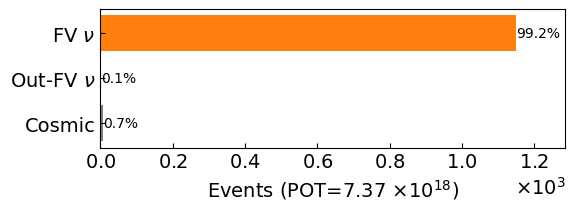

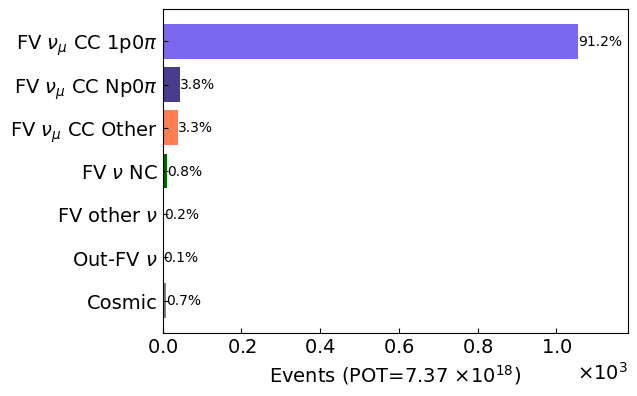

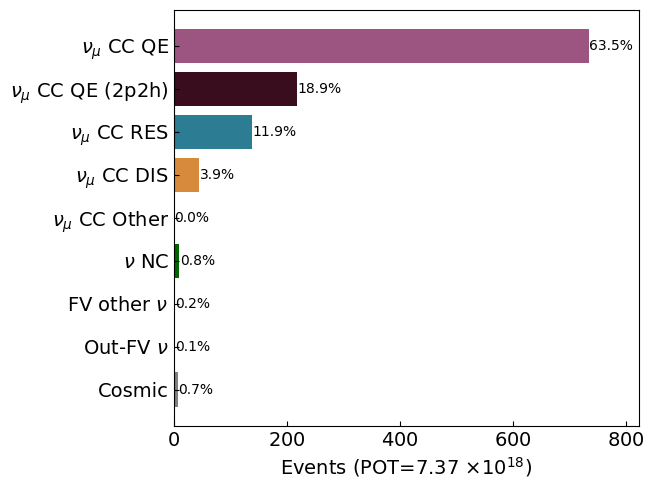

In [ ]:
stage_key = "2prong-mup"

# dfs
mc_df = cut_has_p(mc_df) 
mc_df = cut_p_kinematics(mc_df, p_Plo_th=p_Plo_th, p_Phi_th=p_Phi_th)
data_df = cut_has_p(data_df) 
data_df = cut_p_kinematics(data_df, p_Plo_th=p_Plo_th, p_Phi_th=p_Phi_th)
intime_df = cut_has_p(intime_df)
intime_df = cut_p_kinematics(intime_df, p_Plo_th=p_Plo_th, p_Phi_th=p_Phi_th)

ret = plot_bar_plots(stage_key, mc_df, show_plot=show_plot)

# save dfs
df_dict[stage_key] = mc_df
df_dict_data[stage_key] = data_df
df_dict_intime[stage_key] = intime_df

# save percent break-down
perc_dict_topo[stage_key] = ret["topology"]["perc_list"]
perc_dict_genie[stage_key] = ret["genie"]["perc_list"]

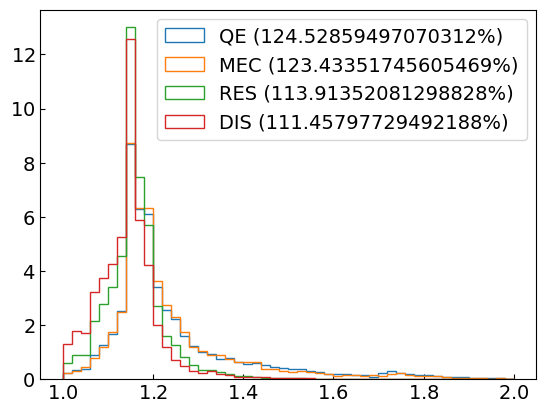

In [ ]:
bins = np.linspace(1, 2, 51)
var = mc_df[IsNuInFV_NumuCC_QE_GiBUU(mc_df)].genweight
mean = var.mean()
plt.hist(var, bins=bins, histtype="step", density=True, label="QE ({:.2f}%)".format(mean*100))

var = mc_df[IsNuInFV_NumuCC_MEC_GiBUU(mc_df)].genweight
mean = var.mean()
plt.hist(var, bins=bins, histtype="step", density=True, label="MEC ({:.2f}%)".format(mean*100))

var = mc_df[IsNuInFV_NumuCC_RES_GiBUU(mc_df)].genweight
mean = var.mean()
plt.hist(var, bins=bins, histtype="step", density=True, label="RES ({:.2f}%)".format(mean*100))

var = mc_df[IsNuInFV_NumuCC_DIS_GiBUU(mc_df)].genweight
mean = var.mean()
plt.hist(var, bins=bins, histtype="step", density=True, label="DIS ({:.2f}%)".format(mean*100))

plt.legend()
plt.show();

# Background Events

In [31]:
mc_df[IsNuInFV_NumuCC_Other(mc_df)].mu_cand.pfp.trk.len[30:50]

__ntuple  entry  rec.slc..index
310       6      1                  52.937572
          165    2                 196.194351
342       91     0                 135.414734
332       0      0                 397.309723
339       53     1                 202.505203
391       182    1                 108.708496
417       56     1                 186.448669
433       179    0                 195.531998
450       17     0                 158.316559
441       156    0                 221.660675
449       68     1                 101.967094
          109    1                  96.792267
489       192    0                  55.322140
482       103    0                 173.945221
513       42     1                 111.375549
518       139    1                 119.628586
511       193    1                  65.128563
505       44     1                 122.325172
          127    1                 100.980667
521       135    1                  70.077499
Name: len, dtype: float32

In [32]:
len(mc_df[IsNuInFV_NumuCC_Other(mc_df)])
mc_df[IsNuInFV_NumuCC_Other(mc_df)].mu.pfp.trk.truth.p[["pdg", "totp", "length"]][0:10]
mc_df[IsNuInFV_NumuCC_Other(mc_df)].p.pfp.trk.truth.p[["pdg", "totp", "length"]][0:10]
# mc_df[IsNuInFV_NumuCC_Other(mc_df)].mu.pfp.trk.rangeP.p_muon[30:50]
# InFV(mc_df[IsNuInFV_NumuCC_Other(mc_df)].mu.pfp.trk.end, det=DETECTOR)
# InFV(mc_df[IsNuInFV_NumuCC_Other(mc_df)].mu_cand.pfp.trk.end, det=DETECTOR)

113

pdg      totp      length
                                                           
                                                           
__ntuple entry rec.slc..index                              
55       43    0                 13.0  1.176809  455.774933
75       5     0                 13.0  0.530433  188.091431
81       106   0                 13.0  0.445898  151.657883
         149   0                 13.0  0.657143  252.810440
35       1     0                 13.0  0.586883  204.665588
45       44    1                 13.0  0.401115  124.705254
97       6     1                 13.0  0.318476   91.834068
118      146   0                 13.0  1.050856  412.311218
148      151   1                 13.0  0.404916  132.517014
134      151   0               2212.0  0.625685   24.240421

pdg      totp      length
                                                                 
                                                                 
__ntuple entry rec.slc..index                                    
55       43    0               1.300000e+01  1.176809  455.774933
75       5     0              -2.147484e+09       NaN         NaN
81       106   0               2.212000e+03  0.299476    2.064546
         149   0               2.212000e+03  1.004248   55.851994
35       1     0               2.110000e+02  0.201372   28.508921
45       44    1               2.212000e+03  0.423742    6.647808
97       6     1               1.300000e+01  0.318476   91.834068
118      146   0               2.212000e+03  0.386266    3.262967
148      151   1               2.212000e+03  1.006537   68.253792
134      151   0               1.300000e+01  0.197523   38.742981

In [33]:
mc_df[IsNuInFV_NumuCC_Other(mc_df)][["nmu_220MeVc", "np_300MeVc", "npi_70MeVc", "npi0"]][0:30]

,,,nmu_220MeVc,np_300MeVc,npi_70MeVc,npi0
,,,,,,
,,,,,,
,,,,,,
,,,,,,
,,,,,,
,,,,,,
,,,,,,
__ntuple,entry,rec.slc..index,,,,
55,43,0,1.0,1.0,0.0,0.0
75,5,0,1.0,1.0,1.0,0.0


# Efficiency Curves

In [34]:
stage_labels = [
    "All reconstructed slices",
    "Not clear cosmic",
    "Vertex in fiducial volume",
    "Nu-score > {}".format(nu_score_th),
    "Has exactly 2 PFPs",
    "Both PFPs contained",
    "Both PFPs have track score > {}".format(0.5),
    "Both track \n(start position - vertex) < {} cm".format(1.2),
    "One track is muon-like",
    "The other is proton-like"
]

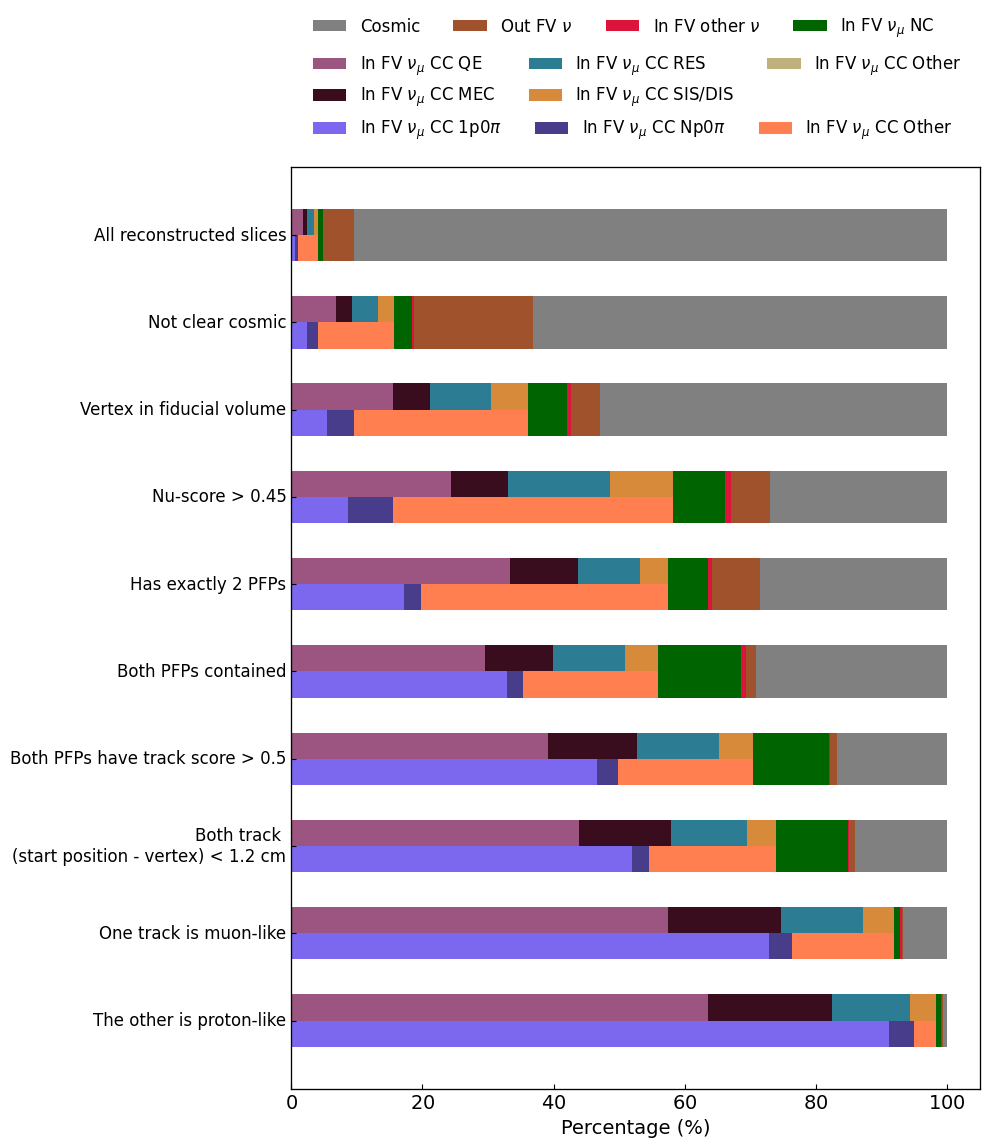

In [35]:
# Patch
from matplotlib.patches import Patch


# Flip the order of stages
stages = list(perc_dict_topo.keys())[::-1]

# Number of stages
n_stages = len(stages)
bar_width = 0.3
y = np.arange(n_stages)

# Prepare data for topo and genie (in flipped order)
topo_data = np.array([perc_dict_topo[stage] for stage in stages])
genie_data = np.array([perc_dict_genie[stage] for stage in stages])

# Flip the stacked order: reverse the stack component axis
topo_data = topo_data[:, ::-1]
genie_data = genie_data[:, ::-1]
topology_colors_flipped = topology_colors
genie_colors_flipped = genie_mode_colors

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

# For legend handles
topo_handles = []
genie_handles = []

# Stacked bars for topo (horizontal) - reversed stack order
left = np.zeros(n_stages)
for i in range(topo_data.shape[1]):
    color = topology_colors_flipped[i] if i < len(topology_colors_flipped) else None
    bar = ax.barh(
        y - bar_width/2,
        topo_data[:, i],
        bar_width,
        left=left,
        color=color,
        label=None if i > 0 else "Topology (unhatched)"
    )
    if i == 0:
        topo_handles.append(bar)
    left += topo_data[:, i]

# Stacked bars for genie (horizontal) - reversed stack order
left = np.zeros(n_stages)
for i in range(genie_data.shape[1]):
    color = genie_colors_flipped[i] if i < len(genie_colors_flipped) else None
    bar = ax.barh(
        y + bar_width/2,
        genie_data[:, i],
        bar_width,
        left=left,
        color=color,
        label=None if i > 0 else "GENIE (light hatch)"
    )
    if i == 0:
        genie_handles.append(bar)
    left += genie_data[:, i]

# Y-axis labels and ticks (flipped order)
ax.set_yticks(y)
ax.set_yticklabels(stage_labels[::-1], rotation=0, va='center', fontsize=12)

# X-axis label
ax.set_xlabel("Percentage (%)")

# ax.set_title("Selected Slice Breakdown")

# Custom legend: note in legend that unhatched is topology and hatched is genie
# from matplotlib.patches import Patch
# legend_handles = [
#     Patch(facecolor=topology_colors_flipped[0], label="Topology (unhatched)"),
#     Patch(facecolor=genie_colors_flipped[0], hatch='x', alpha=0.7, label="GENIE (light hatch)")
# ]
# ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)

plt.tight_layout()

common_handles = []
common_colors = ["gray", "sienna", "crimson", "darkgreen"]
common_modes = ["Cosmic", r"Out FV $\nu$", r"In FV other $\nu$", r"In FV $\nu_{\mu}$ NC"]
for i in range(len(common_colors)):
    common_handles.append(Patch(facecolor=common_colors[i], label=common_modes[i]))

genie_spec_handles = []
genie_spec_colors = ["#BFB17C", "#D88A3B", "#2c7c94", "#390C1E", "#9b5580"]
genie_spec_modes = [r"In FV $\nu_{\mu}$ CC Other", r"In FV $\nu_{\mu}$ CC SIS/DIS", r"In FV $\nu_{\mu}$ CC RES", r"In FV $\nu_{\mu}$ CC MEC", r"In FV $\nu_{\mu}$ CC QE"]
for i in range(len(genie_spec_colors)):
    genie_spec_handles.append(Patch(facecolor=genie_spec_colors[i], label=genie_spec_modes[i]))

topo_spec_handles = []
topo_spec_colors = ["coral", "darkslateblue", "mediumslateblue"]
topo_spec_modes = [r"In FV $\nu_{\mu}$ CC Other", r"In FV $\nu_{\mu}$ CC Np0$\pi$", r"In FV $\nu_{\mu}$ CC 1p0$\pi$"]
for i in range(len(topo_spec_colors)):
    topo_spec_handles.append(Patch(facecolor=topo_spec_colors[i], label=topo_spec_modes[i]))

ax.legend(handles=common_handles, loc='upper left', 
          bbox_to_anchor=(0.01, 1.18), ncol=4, fontsize=12, frameon=False)
ax_1 = ax.twinx()
ax_1.legend(handles=genie_spec_handles[::-1], loc='upper left', 
            bbox_to_anchor=(0.01, 1.14), ncol=3, fontsize=12, frameon=False)
ax_2 = ax.twinx()
ax_2.legend(handles=topo_spec_handles[::-1], loc='upper left', 
            bbox_to_anchor=(0.01, 1.07), ncol=4, fontsize=12, frameon=False)
ax_1.set_yticks([])
ax_2.set_yticks([])

save_name = save_fig_dir + "/summary-selected_slice_breakdown.png"
if save_fig:
    plt.savefig(save_name, dpi=300, bbox_inches="tight")

plt.show();

In [36]:
import statsmodels.api as sm

def eff_err(success,total):  # success/total
    err = [[],[]]
    eff = success/total
    for i in range(len(success)):
        this_success = success[i]
        this_tot = total[i]
        interval = sm.stats.proportion_confint(this_success,this_tot,method='wilson')
        err[0].append(abs(eff[i]-interval[0]))
        err[1].append(abs(eff[i]-interval[1]))
    return err

final purity: 91.17%


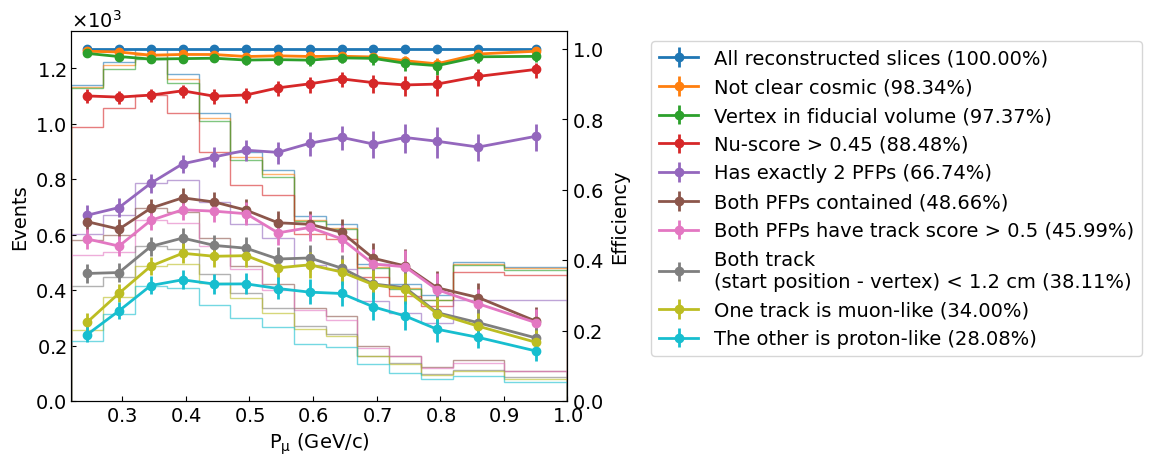

In [37]:
# efficiency plot as a function of a variable
var_name = ("mu", "totp") 
var_config = VariableConfig.muon_momentum()
var_savename = var_config.var_save_name
xlabel = var_config.var_labels[0]
bins = var_config.bins

fig, ax = plt.subplots()
ax_eff = ax.twinx()
keys = df_dict.keys()
tot_evts = len(df_dict["allreco"][IsNuInFV_NumuCC_1p0pi(df_dict["allreco"])])
rate_list = []
for kidx, key in enumerate(keys):
    stage_df = df_dict[key]
    this_color = "C" + str(kidx)
    is_signal = IsNuInFV_NumuCC_1p0pi(stage_df)
    stage_df = stage_df[is_signal]
    if key == "2prong-mup":
        print("final purity: {:.2f}%".format(100 * len(stage_df) / len(df_dict["2prong-mup"])))
    vardf = stage_df[var_name]
    # append integrated efficiency to the label
    int_eff = len(stage_df) / tot_evts
    this_label = stage_labels[kidx] + " ({:.2f}%)".format(int_eff*100)
    n, bins, _ = ax.hist(vardf, bins=bins, histtype="step", label=this_label, alpha=0.6)
    if key == "allreco":
        tot_rate = n

    # if "2prong" in key:
        # n_2prong 
    this_eff = n / tot_rate
    this_eff_err = eff_err(n, tot_rate)
    bin_centers = (bins[:-1] + bins[1:])/2
    # ax_eff.plot(bin_centers, this_eff, label=this_label, color=this_color)
    ax_eff.errorbar(bin_centers, this_eff, yerr=this_eff_err, fmt="o-", color=this_color, label=this_label)

ax.set_xlabel(xlabel)
ax.set_ylabel("Events")
ax_eff.set_ylabel("Efficiency")
ax_eff.set_ylim(0, 1.05)

# plt.axvline(mu_low_th, color="red", linestyle="--")
plt.xlim(bins[0], bins[-1])
plt.legend(bbox_to_anchor=(1.15, 1.0))
save_name = save_fig_dir + "/efficiency_plot_{}.png".format(var_savename)
if save_fig:
    plt.savefig(save_name, dpi=300, bbox_inches="tight")
plt.show();

# Selected Events

In [38]:
eps = 1e-6

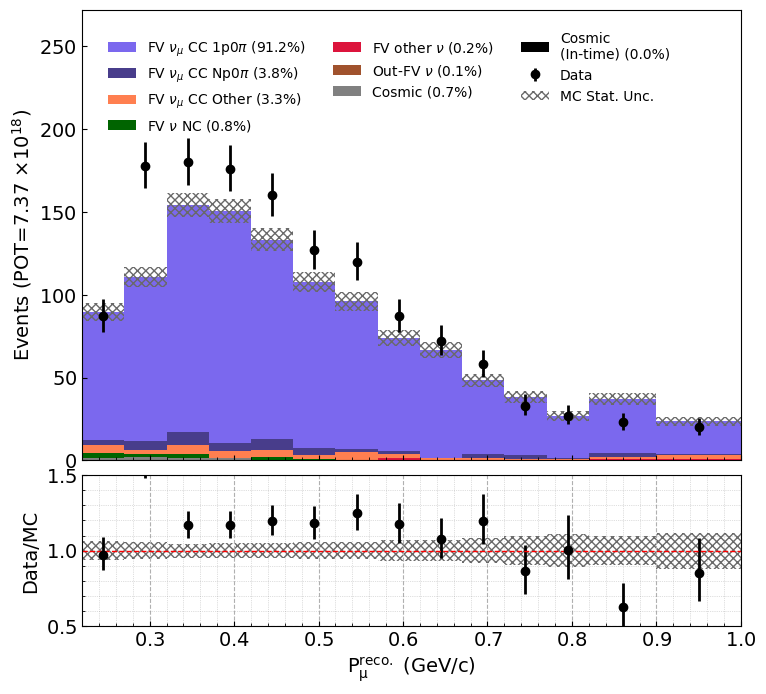

numu NC 29


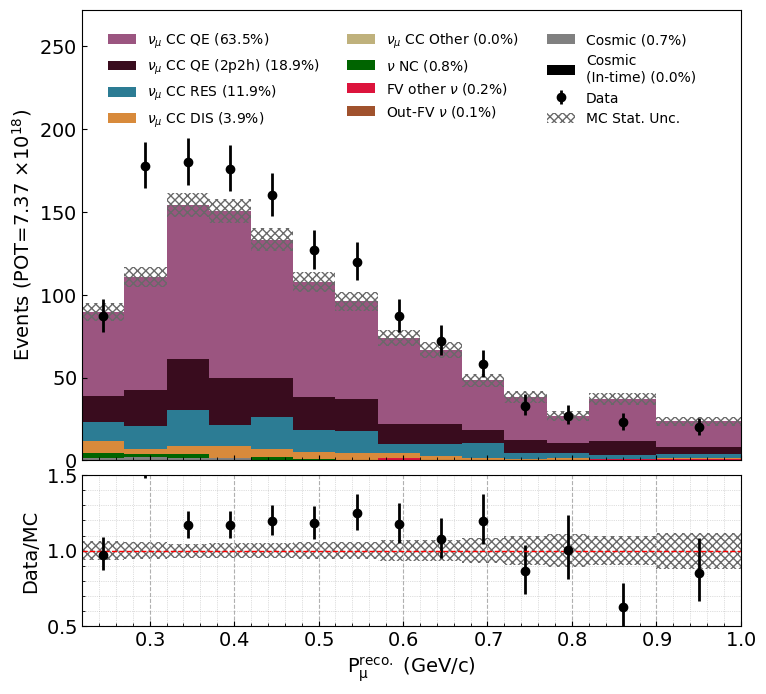

0.77088948787062


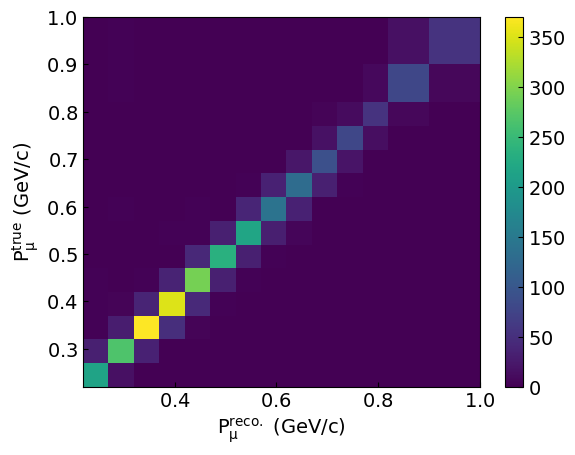

In [39]:
# muon momentum 
var_config = VariableConfig.muon_momentum()
evtdf = mc_df
vardf = mc_df.mu_cand.pfp.trk.rangeP.p_muon
vardf_data = data_df.mu_cand.pfp.trk.rangeP.p_muon
vardf_intime = intime_df.mu_cand.pfp.trk.rangeP.p_muon
bins = var_config.bins
vardf = np.clip(vardf, bins[0], bins[-1] - eps)
vardf_data = np.clip(vardf_data, bins[0], bins[-1] - eps)
vardf_intime = np.clip(vardf_intime, bins[0], bins[-1] - eps)

# plot
plot_labels = [var_config.var_labels[1], 
               "Events (POT={})".format(pot_str), ""]

plot_type = "topology"
save_name = save_fig_dir + "/selected-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist_topo = hist_plot(plot_type,
                          evtdf, vardf, 
                          vardf_data, vardf_intime,
                          bins, 
                          plot_labels=plot_labels,
                          save_fig=save_fig, save_name=save_name)

plot_type = "genie"
save_name = save_fig_dir + "/selected-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist_genie = hist_plot(plot_type,
                          evtdf, vardf, 
                          vardf_data, vardf_intime,
                          bins, 
                          generator=generator,
                          plot_labels=plot_labels,
                          save_fig=save_fig, save_name=save_name)

var_reco = mc_df[var_config.var_evt_reco_col]
var_truth = mc_df[var_config.var_evt_truth_col]
n, bins, _, _ = plt.hist2d(var_reco, var_truth, bins=var_config.bins)
perc_diag = np.sum(np.diag(n)) / np.sum(n)
print(perc_diag)
plt.colorbar()
plt.xlabel(var_config.var_labels[1])
plt.ylabel(var_config.var_labels[2])
plt.show();